# Exploratory Data Analysis for Titanic Dataset

Step 1: Importing Libraries

In [ ]:
# Import NumPy for numerical operations and array manipulation.
import numpy as np

# Import Pandas for data manipulation and analysis, especially with DataFrames.
import pandas as pd

# Import Matplotlib's pyplot for creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization, built on Matplotlib.
import seaborn as sns

# Configure Matplotlib to display plots inline in the Jupyter/Colab environment.
%matplotlib inline

# Set default aesthetic parameters for plots to make them look good.
sns.set()

# Ignore harmless warnings that might be generated during execution.
import warnings
warnings.filterwarnings('ignore')

Step 2: Loading the Dataset

In [ ]:
# Import the files module from google.colab to handle file uploads
from google.colab import files

# Create an uploader widget and get the uploaded files
uploaded = files.upload()

# Get the name of the uploaded file
file_name = next(iter(uploaded))

# Load the uploaded CSV file into a pandas DataFrame
df = pd.read_csv(file_name)

# Display the first 5 rows of the DataFrame to confirm successful loading
print(f"Successfully loaded {file_name} into a DataFrame.")
display(df.head())

Saving Titanic dataset.csv to Titanic dataset.csv
Successfully loaded Titanic dataset.csv into a DataFrame.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Step 3: Understanding the Dataset

In [ ]:
df.tail() #To display the last five rows in the dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [ ]:
df.shape #To show the number of rows and columns in the dataset

(418, 12)

In [ ]:
df.columns #To display all the columns in the dataset

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Data Dictionary:**


PassengerId: A unique identification number for each passenger.

Survived: Indicates whether the passenger survived (1) or not (0).

Pclass: The passenger's class (1st, 2nd, or 3rd).

Name: The name of the passenger.

Sex: The sex of the passenger (male or female).

Age: The age of the passenger.

SibSp: The number of siblings/spouses aboard the Titanic.

Parch: The number of parents/children aboard the Titanic.

Ticket: The ticket number.

Fare: The fare paid by the passenger.

Cabin: The cabin number.

Embarked: The port where the passenger embarked (C = Cherbourg, Q = Queenstown, S = Southampton).

In [ ]:
df.info() #To show columns and the number of non blank entries


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df.dtypes #To show the data types of all the columns

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.isnull().sum() #to show the total number of blank cells in the dataset

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [ ]:
df.describe() #to display the statistical summary of your dataset

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Step 4: Data Cleaning

In [ ]:
#To handle missing values, replace missing age with the median
df['Age'].fillna(df['Age'].median(), inplace=True) #replace missing fare with the median
df['Fare'].fillna(df['Fare'].median(), inplace=True) #replace missing cabin with unknown
df['Cabin'].fillna('Unknown', inplace=True)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum() #to check for duplicate rows

np.int64(0)

In [ ]:
df['Age'] = df['Age'].astype(int) #converting age column from float to integer
df['Sex'] = df['Sex'].astype('category') #converting sex column to categorical
df['Pclass'] = df['Pclass'].astype('category') #converting Pclass column to category
df['Embarked'] = df['Embarked'].astype('category') #converting embarked column to categorical
df['Cabin'] = df['Cabin'].astype('category') #converting cabin column to categorical

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,category
Name,object
Sex,category
Age,int64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df['Sex'].value_counts() #to check for inconsistencies in each of the columns

,count
Sex,
male,266
female,152


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,270
C,102
Q,46


In [ ]:
df['Cabin'].value_counts()

,count
Cabin,
Unknown,327
B57 B59 B63 B66,3
C89,2
B45,2
A34,2
...,...
F E57,1
F2,1
F G63,1


Text(0, 0.5, 'Age')

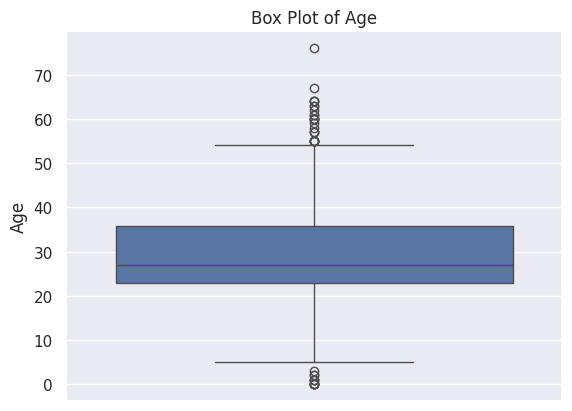

In [ ]:
# A boxplot to visualize age and outliers
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')

Text(0, 0.5, 'Fare')

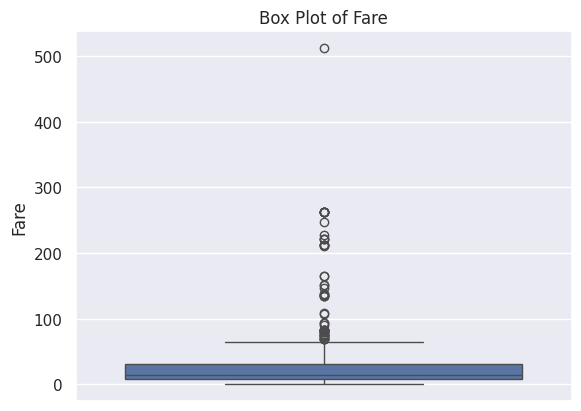

In [ ]:
# A boxplot to visualize fare and outliers
sns.boxplot(y=df['Fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 non-null    int64   
 1   Survived     418 non-null    int64   
 2   Pclass       418 non-null    category
 3   Name         418 non-null    object  
 4   Sex          418 non-null    category
 5   Age          418 non-null    int64   
 6   SibSp        418 non-null    int64   
 7   Parch        418 non-null    int64   
 8   Ticket       418 non-null    object  
 9   Fare         418 non-null    float64 
 10  Cabin        418 non-null    category
 11  Embarked     418 non-null    category
dtypes: category(4), float64(1), int64(5), object(2)
memory usage: 30.9+ KB


Step 5: **UNIVARIATE ANALYSIS**

**Numerical Variable Analysis**

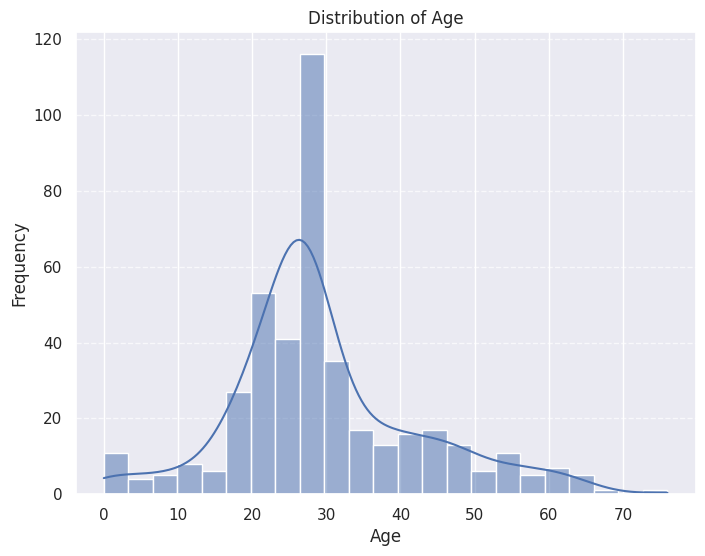

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], kde=True)
plt.title(f'Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Insight 1:The most occuring age range onboard this ship around 30 years old. We have more young adults onboard this ship.

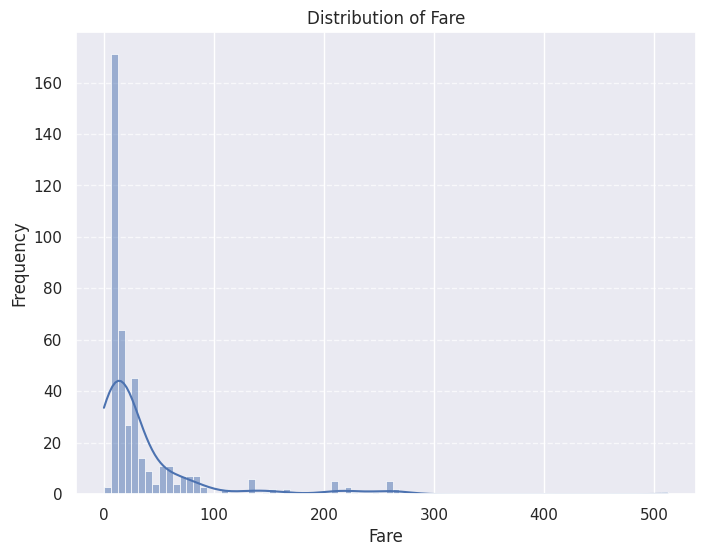

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Fare'], kde=True)
plt.title(f'Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

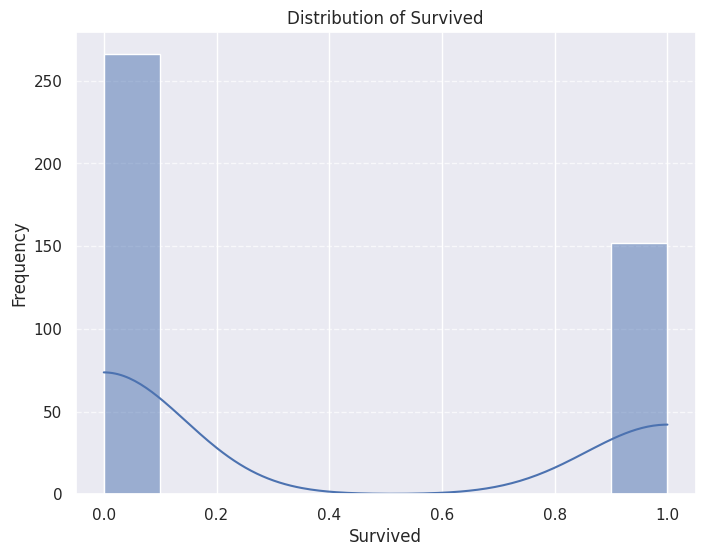

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Survived', data=df, kde=True)
plt.title('Distribution of Survived') # Set the chart title
plt.xlabel('Survived') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

### Insight : Most passengers did not survive. The number of people who did not survive is significantly higher than those who did.

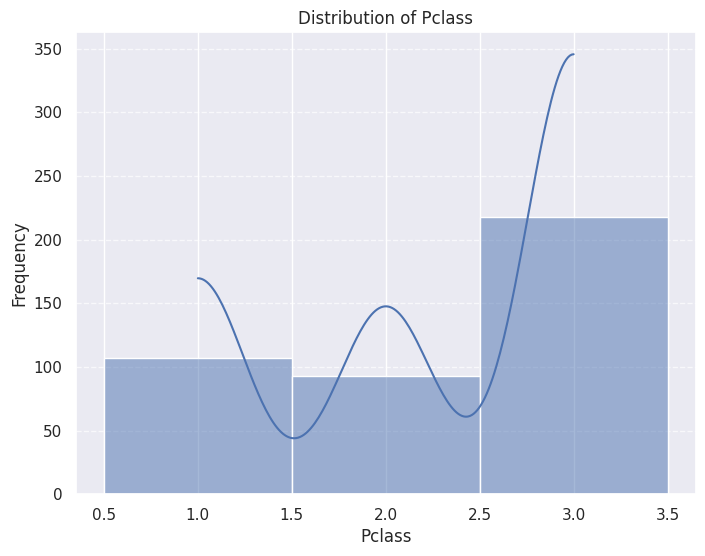

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Pclass', data=df, kde=True)
plt.title('Distribution of Pclass') # Set the chart title
plt.xlabel('Pclass') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight: The Pclass chart shows the distribution of passengers across the different passenger classes. From the plot, it's clear that the largest number of passengers were in the 3rd class, followed by the 1st class, and the fewest passengers were in the 2nd class.

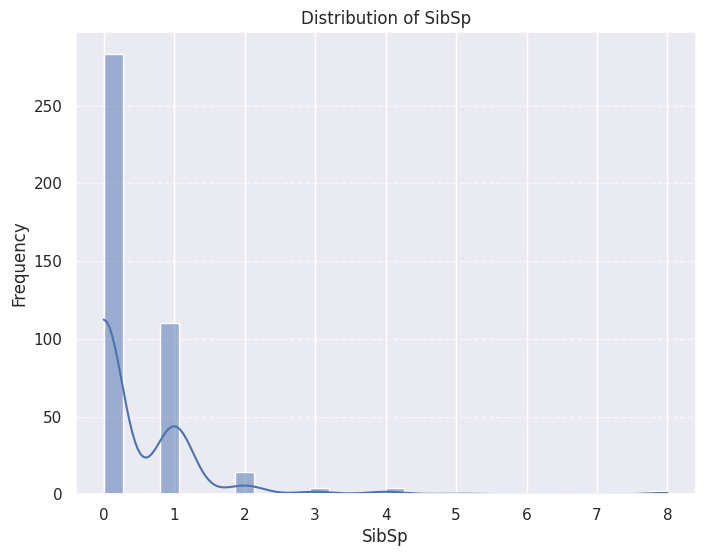

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['SibSp'], kde=True)
plt.title(f'Distribution of SibSp')
plt.xlabel('SibSp')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Insight: The histogram for 'SibSp' (siblings/spouses aboard) shows that the vast majority of passengers traveled either alone (SibSp = 0) or with one sibling/spouse (SibSp = 1). The frequency significantly drops for higher numbers of siblings/spouses, indicating that large family groups of this type were less common.

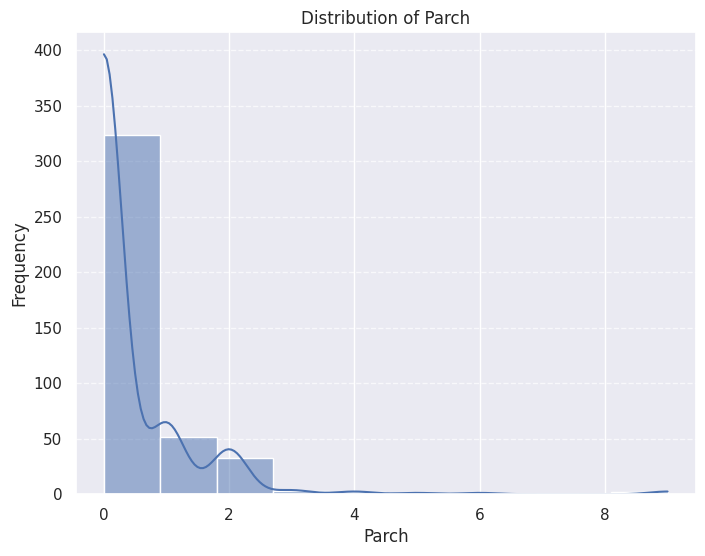

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Parch'], kde=True)
plt.title(f'Distribution of Parch')
plt.xlabel('Parch')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Insight:
The histogram for 'Parch' (parents/children aboard) indicates that the vast majority of passengers traveled without parents or children (Parch = 0). A smaller but still significant number traveled with one or two parents/children. The frequency sharply declines for higher numbers, suggesting that passengers traveling with a larger number of parents/children were rare.



**Categorical Variable Analysis**

Frequency Counts:


,count
Sex,
male,266
female,152


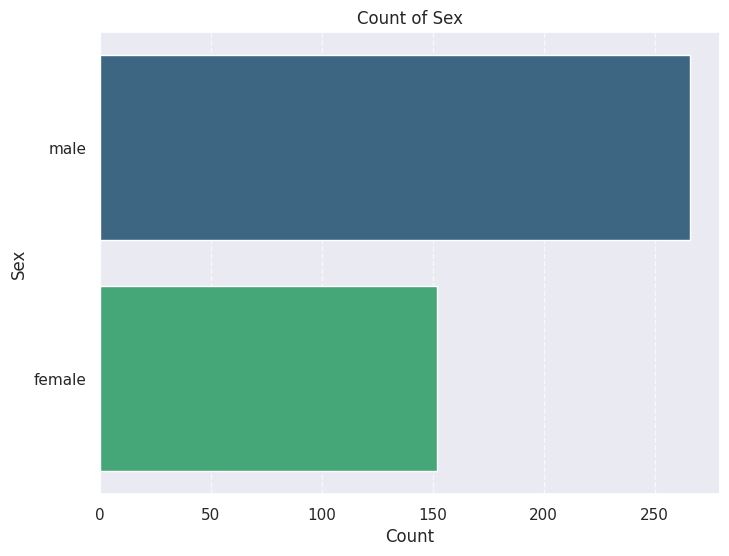

In [ ]:
col = 'Sex'
# Display frequency counts for the categorical column
# .value_counts() shows how many times each unique value appears.
print("Frequency Counts:")
display(df[col].value_counts())

# Create a count plot for the categorical column
# Count plots show the number of occurrences of each category in a dataset.
plt.figure(figsize=(8, 6))
sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis') # Use y for horizontal bars if categories are many
plt.title(f'Count of {col}') # Set the chart title
plt.xlabel('Count') # Set the x-axis label
plt.ylabel(col) # Set the y-axis label
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight: The count plot for 'Sex' showed that there were significantly more male passengers (266) than female passengers (152) in the dataset.

Frequency Counts:


,count
Cabin,
Unknown,327
B57 B59 B63 B66,3
C89,2
B45,2
A34,2
...,...
F E57,1
F2,1
F G63,1


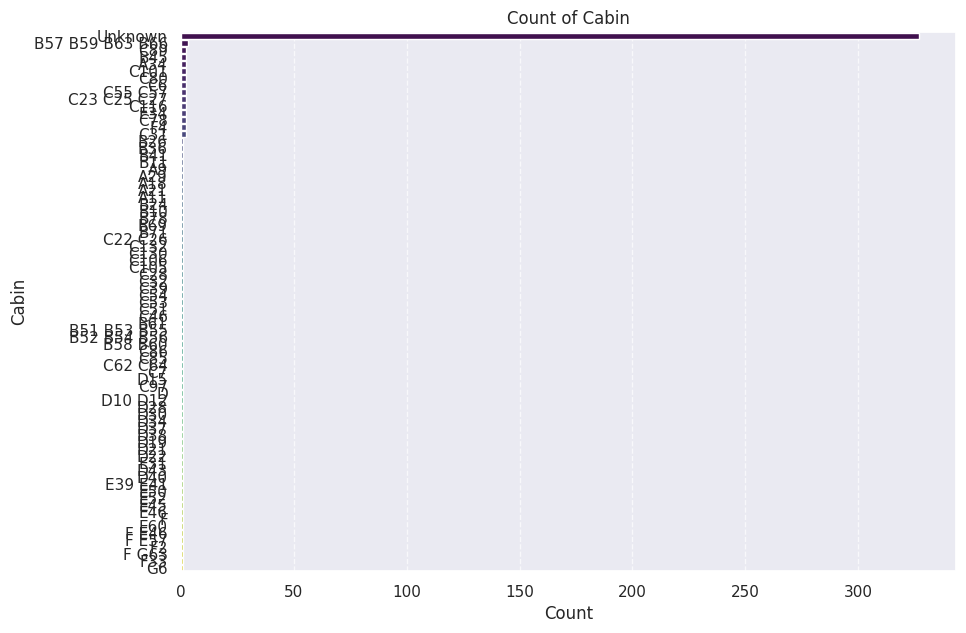

In [ ]:
col = 'Cabin'
# Display frequency counts for the categorical column
# .value_counts() shows how many times each unique value appears.
print("Frequency Counts:")
display(df[col].value_counts())

# Create a count plot for the categorical column
# Count plots show the number of occurrences of each category in a dataset.
plt.figure(figsize=(10, 7))
sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis') # Use y for horizontal bars if categories are many
plt.title(f'Count of {col}') # Set the chart title
plt.xlabel('Count') # Set the x-axis label
plt.ylabel(col) # Set the y-axis label
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

### Insight:

The count plot for the 'Cabin' column reveals a significant number of passengers (`327`) with 'Unknown' cabin information, indicating a high proportion of missing data in this feature. Among the known cabins, many have a count of 1, suggesting a wide variety of unique cabin assignments rather than common cabin types shared by many passengers. This high cardinality and missing data presence for 'Cabin' suggests that it might be challenging to use directly for analysis without further feature engineering or imputation strategies.

Frequency Counts:


,count
Embarked,
S,270
C,102
Q,46


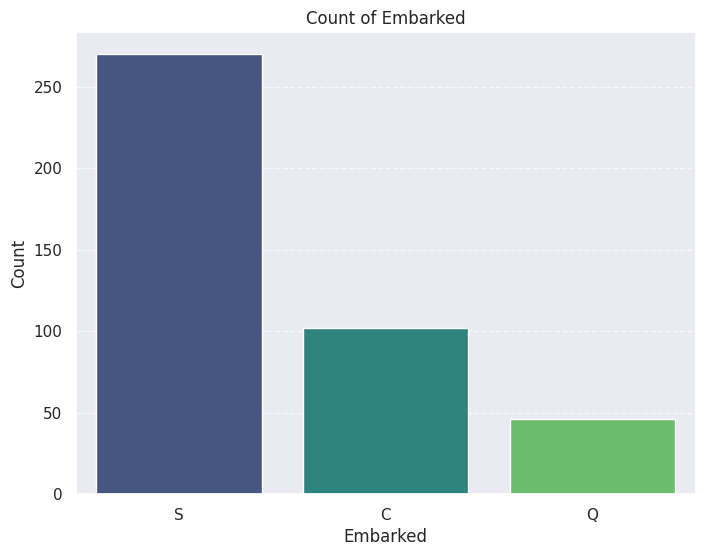

In [ ]:
col = 'Embarked'
# Display frequency counts for the categorical column
# .value_counts() shows how many times each unique value appears.
print("Frequency Counts:")
display(df[col].value_counts())

# Create a count plot for the categorical column
# Count plots show the number of occurrences of each category in a dataset.
plt.figure(figsize=(8, 6))
sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis') # Use x for vertical bars
plt.title(f'Count of {col}') # Set the chart title
plt.xlabel(col) # Set the x-axis label
plt.ylabel('Count') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

### Insight:

The count plot for the 'Embarked' column reveals that the majority of passengers embarked from Southampton ('S'), followed by Cherbourg ('C'), and then Queenstown ('Q'). This distribution indicates that Southampton was the primary departure port for passengers in this dataset.

**Summary of Key Observations from Univariate Analysis**

From the univariate analysis, here are the key observations:

Age: The most common age range for passengers was around 30 years old, indicating a predominance of young adults.

Survival: Most passengers did not survive, with a significantly higher number of non-survivors compared to survivors.

Passenger Class (Pclass): The largest group of passengers was in 3rd class, followed by 1st class, and then 2nd class.

Siblings/Spouses Aboard (SibSp): The majority of passengers traveled either alone or with one sibling/spouse, with larger family groups being less common.

Parents/Children Aboard (Parch): Most passengers traveled without parents or children, and the number decreased sharply for those with more family members of this type.

Sex: There were significantly more male passengers (266) than female passengers (152) in the dataset.

Cabin: A substantial portion of 'Cabin' information was missing ('Unknown'), and among the known cabins, there was a high diversity of unique assignments.

Embarked: The primary embarkation port was Southampton ('S'), followed by Cherbourg ('C'), and then Queenstown ('Q').

**Step 6: Bivariate Analysis**

Relationship 1: Sex vs Survived

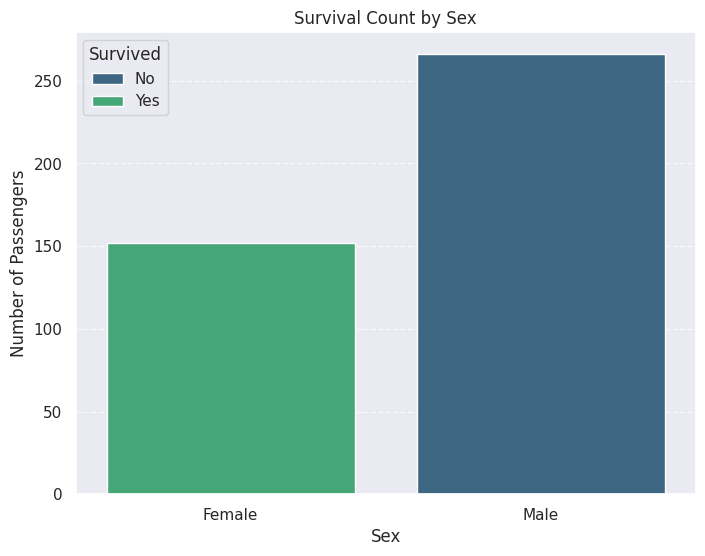

In [ ]:
# Create a count plot to visualize the relationship between 'Sex' and 'Survived'
# 'x' is 'Sex', 'hue' is 'Survived' to group bars by survival status, and 'data' is our DataFrame 'df'.
# palette='viridis' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Sex') # Set the chart title
plt.xlabel('Sex') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.xticks(ticks=[0, 1], labels=['Female', 'Male']) # Custom x-axis labels for clarity
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

### Insight : The plot clearly shows that a significantly higher proportion of female passengers survived compared to male passengers. This suggests that 'Sex' was a critical factor in survival rates during the Titanic disaster.

Relationship 2: Pclass vs Survived

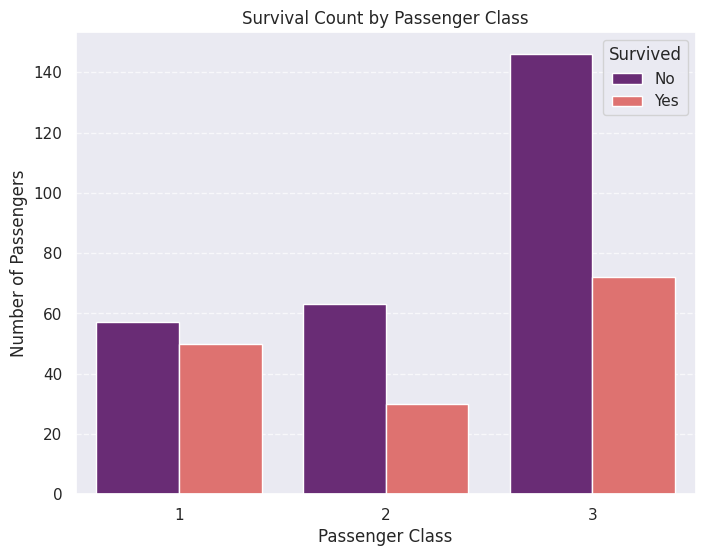

In [ ]:
# Create a count plot to visualize the relationship between 'Pclass' and 'Survived'
# 'x' is 'Pclass', 'hue' is 'Survived' to group bars by survival status, and 'data' is our DataFrame 'df'.
# palette='magma' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='magma')
plt.title('Survival Count by Passenger Class') # Set the chart title
plt.xlabel('Passenger Class') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

Insight: The chart for 'Pclass vs Survived' clearly indicates that passenger class was a strong determinant of survival. First-class passengers generally had the highest survival rates, while third-class passengers had the lowest. This suggests that socio-economic status, as reflected by class, significantly impacted survival chances.

Relationship 3: Age vs Survived

In [ ]:
# Create age bins
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

display(df[['Age', 'AgeGroup']].head())

,Age,AgeGroup
0,34,30-39
1,47,40-49
2,62,60-69
3,27,20-29
4,22,20-29


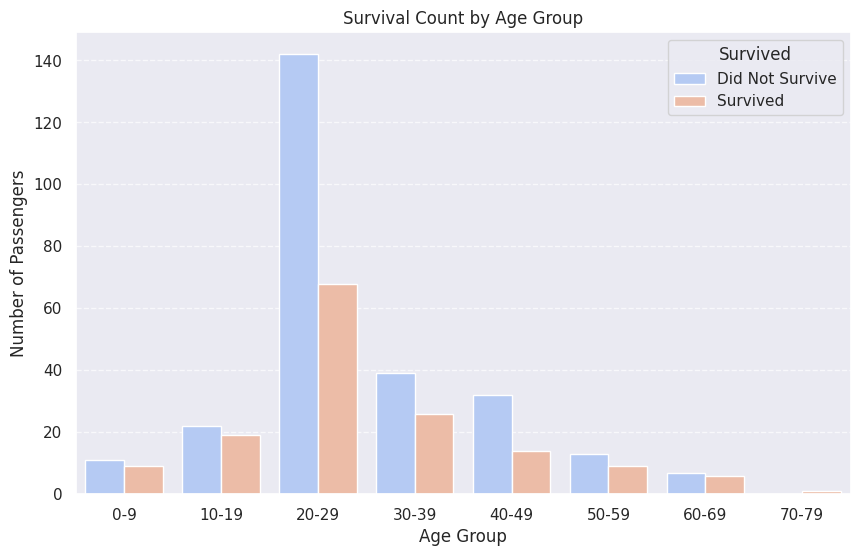

In [ ]:
# Create a count plot to visualize the relationship between 'AgeGroup' and 'Survived'
plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', hue='Survived', data=df, palette='coolwarm', order=age_labels)
plt.title('Survival Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['Did Not Survive', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 5: This plot shows the distribution of survivors and non-survivors across different age groups. We can observe that survival rates vary by age, with some groups having a higher chance of survival than others. For example, children (0-9) seem to have a relatively higher survival rate compared to young adults (20-29).

Relationship 4: Fare vs Survived

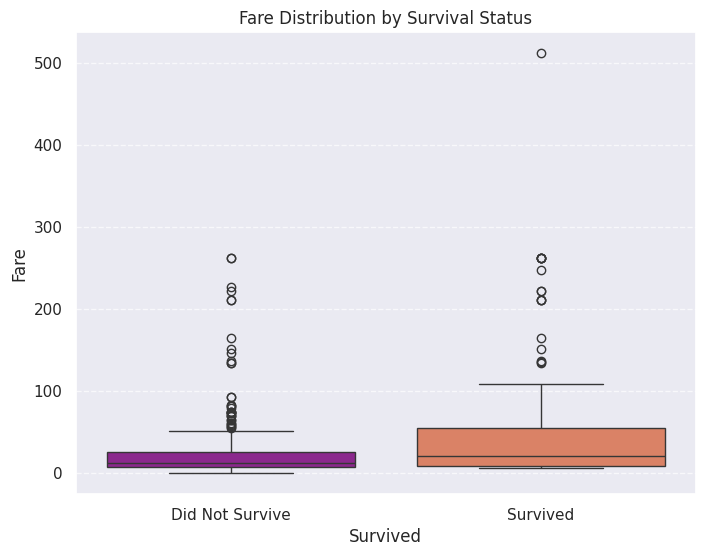

In [ ]:
# Create a box plot to visualize the distribution of 'Fare' for 'Survived' and 'Not Survived'
# 'x' is 'Survived', 'y' is 'Fare', and 'data' is our DataFrame 'df'.
# palette='plasma' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Fare', data=df, palette='plasma')
plt.title('Fare Distribution by Survival Status') # Set the chart title
plt.xlabel('Survived') # Set the x-axis label
plt.ylabel('Fare') # Set the y-axis label
plt.xticks(ticks=[0, 1], labels=['Did Not Survive', 'Survived']) # Custom x-axis labels
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

Insight: The 'Fare vs Survived' chart (specifically the box plot) shows that passengers who paid higher fares tended to have a better chance of survival. This observation is likely linked to the strong correlation between Fare and Pclass, where higher fares are typically associated with higher passenger classes (e.g., first class), which had better survival rates.

Relationship 5: Sibsp vs Survival

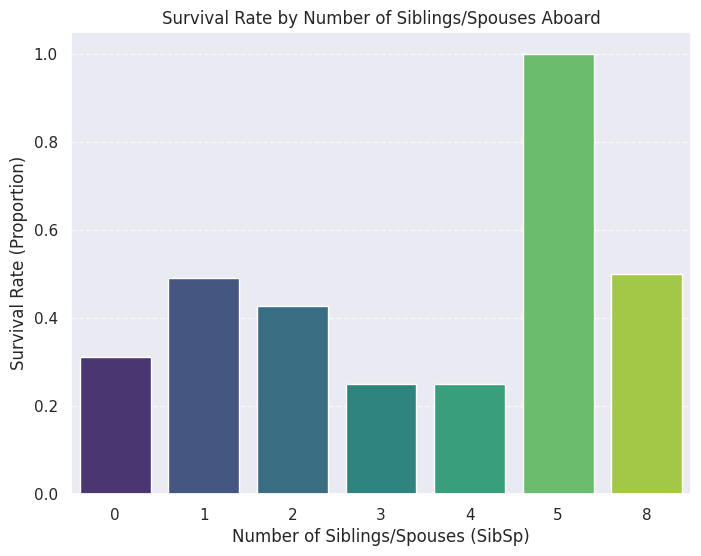

In [ ]:
# Calculate the mean survival rate for each 'SibSp' group
# This gives us the proportion of people who survived for each number of siblings/spouses.
mean_survival_sibsp = df.groupby('SibSp')['Survived'].mean().reset_index()
# Create a bar plot to visualize the average survival rate by 'SibSp'
# 'x' is 'SibSp', 'y' is the mean 'Survived', and 'data' is our calculated DataFrame.
# palette='viridis' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.barplot(x='SibSp', y='Survived', data=mean_survival_sibsp, palette='viridis')
plt.title('Survival Rate by Number of Siblings/Spouses Aboard') # Set the chart title
plt.xlabel('Number of Siblings/Spouses (SibSp)') # Set the x-axis label
plt.ylabel('Survival Rate (Proportion)') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

Insight: The 'SibSp vs Survived' chart shows that passengers with one sibling or spouse (SibSp=1) had a higher survival rate compared to those traveling alone (SibSp=0). Interestingly, the survival rate decreases for larger numbers of siblings/spouses, suggesting that traveling with a very large family group might have negatively impacted survival chances, or these groups might have been in less favorable conditions.



Relationship 6: Parch vs Survived

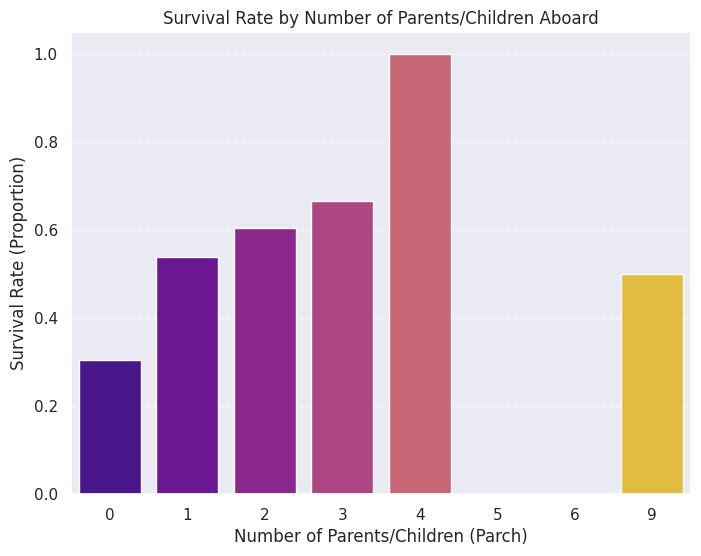

In [ ]:
# Calculate the mean survival rate for each 'Parch' group
# This gives us the proportion of people who survived for each number of parents/children.
mean_survival_parch = df.groupby('Parch')['Survived'].mean().reset_index()

# Create a bar plot to visualize the average survival rate by 'Parch'
# 'x' is 'Parch', 'y' is the mean 'Survived', and 'data' is our calculated DataFrame.
# palette='plasma' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.barplot(x='Parch', y='Survived', data=mean_survival_parch, palette='plasma')
plt.title('Survival Rate by Number of Parents/Children Aboard') # Set the chart title
plt.xlabel('Number of Parents/Children (Parch)') # Set the x-axis label
plt.ylabel('Survival Rate (Proportion)') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

Insight:The 'Parch vs Survived' chart indicates that passengers with 1 or 2 parents/children (Parch=1 or Parch=2) had a higher survival rate than those traveling alone (Parch=0). Similar to 'SibSp', this suggests that traveling with a small family unit (parents/children) could be beneficial for survival. However, the survival rate decreases for larger Parch values, and in some cases, becomes 0, implying that traveling with a very large number of parents/children might have reduced survival chances.



Relationship 7: Embarked vs Survived

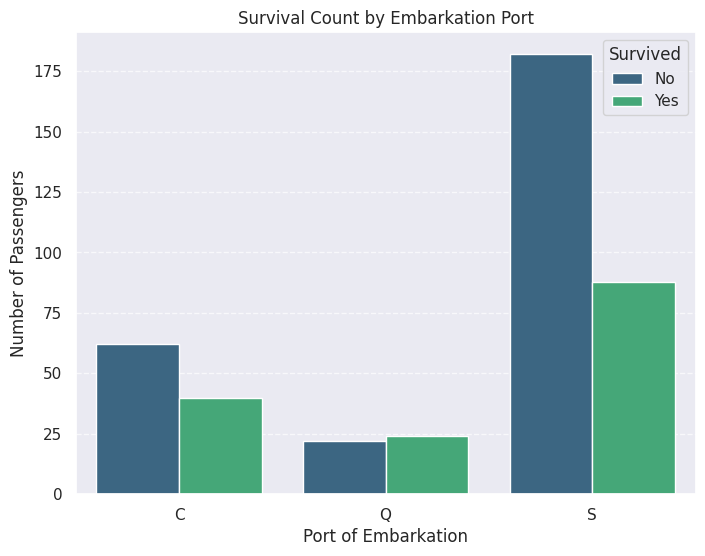

In [ ]:
# Create a count plot to visualize the relationship between 'Embarked' and 'Survived'
# 'x' is 'Embarked', 'hue' is 'Survived' to group bars by survival status, and 'data' is our DataFrame 'df'.
# palette='viridis' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Embarkation Port') # Set the chart title
plt.xlabel('Port of Embarkation') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

Insight: The 'Embarked vs Survived' chart shows varying survival rates across different embarkation ports. Passengers who embarked from Cherbourg ('C') appear to have had a notably higher survival rate compared to those from Southampton ('S') and Queenstown ('Q'). This could be due to differences in passenger demographics (e.g., Pclass, Fare) or social networks among those embarking from each port.

**Summary of Bivariate Analysis**

From the bivariate analysis, here are the key observations:

*   **Sex vs. Survival:** Female passengers had a significantly higher survival rate compared to male passengers, indicating a strong gender bias in survival outcomes.
*   **Pclass vs. Survival:** Passenger class played a crucial role in survival, with first-class passengers exhibiting the highest survival rates and third-class passengers the lowest.
*   **Age vs. Survival:** Survival rates varied across age groups, with children (0-9 years) generally having a better chance of survival. Survival rates for young adults and elderly passengers showed different trends.
*   **Fare vs. Survival:** Passengers who paid higher fares tended to have higher survival rates, which is likely correlated with their passenger class (higher fares for higher classes).
*   **SibSp vs. Survival:** Passengers with one sibling or spouse (`SibSp=1`) had a higher survival rate than those traveling alone. However, larger numbers of siblings/spouses (`SibSp` > 1) correlated with decreased survival rates.
*   **Parch vs. Survival:** Similar to `SibSp`, passengers with 1 or 2 parents/children (`Parch=1` or `Parch=2`) had better survival chances than those traveling alone. Larger family sizes in terms of parents/children often led to lower survival rates.
*   **Embarked vs. Survival:** The port of embarkation influenced survival rates. Passengers who embarked from Cherbourg ('C') showed a higher survival rate compared to those from Southampton ('S') and Queenstown ('Q').

Step 7: Multivariate Analysis

Correlation Heatmap of Numerical Variables

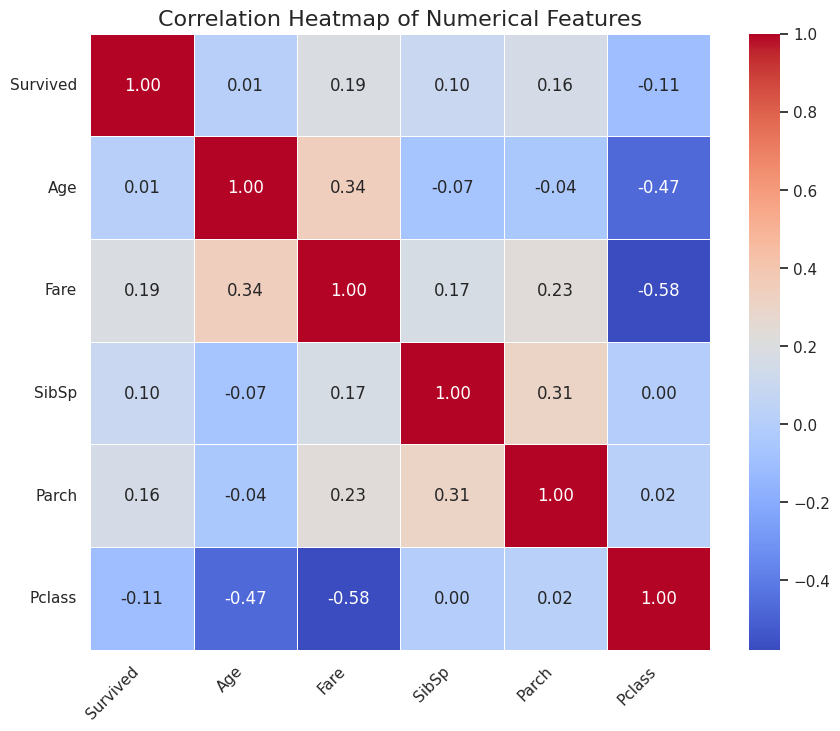

In [ ]:
numerical_features = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

# Calculate the pairwise correlation between selected numerical features.
# The .corr() method computes the standard correlation coefficient.
correlation_matrix = df[numerical_features].corr()

# Create a heatmap to visualize the correlation matrix.
plt.figure(figsize=(10, 8)) # Set the size of the plot for optimal readability.
sns.heatmap(correlation_matrix,
            annot=True,     # Display the correlation coefficients on the heatmap cells.
            cmap='coolwarm',  # Use a diverging colormap ('coolwarm' shows positive/negative correlations).
            fmt='.2f',      # Format the annotations to two decimal places.
            linewidths=.5)  # Add lines between cells for better visual separation.
plt.title('Correlation Heatmap of Numerical Features', fontsize=16) # Set a descriptive chart title.
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better legibility.
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal.
plt.show() # Display the generated plot.

Survival Rate by Pclass and Sex

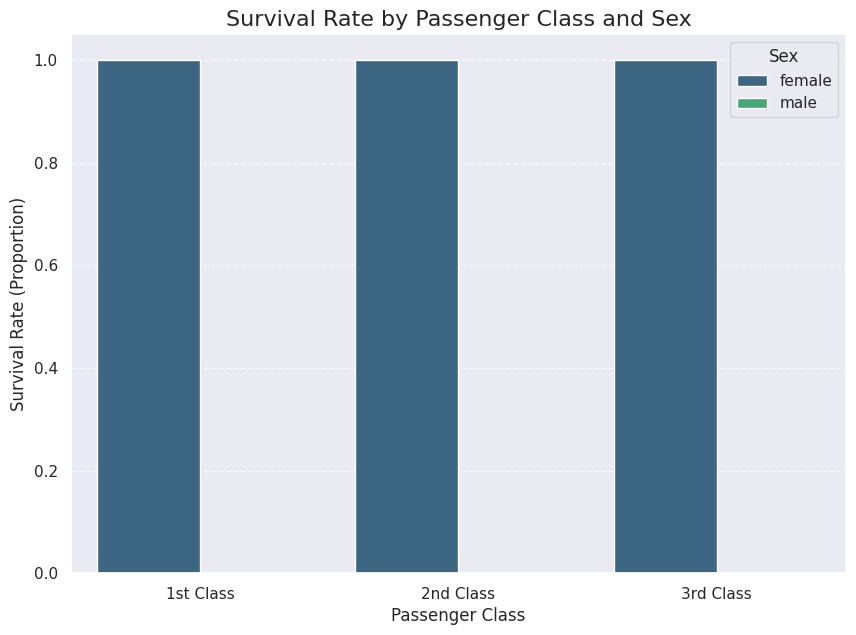

In [ ]:
mean_survival_pclass_sex = df.groupby(['Pclass', 'Sex'], observed=False)['Survived'].mean().reset_index()

# Create a grouped bar plot to visualize the survival rate.
# 'x' represents Pclass on the horizontal axis.
# 'y' represents the calculated mean 'Survived' (survival rate) on the vertical axis.
# 'hue' is set to 'Sex' to create separate bars for 'male' and 'female' within each Pclass group.
plt.figure(figsize=(10, 7)) # Set the size of the plot for better readability.
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=mean_survival_pclass_sex, palette='viridis')
plt.title('Survival Rate by Passenger Class and Sex', fontsize=16) # Set a descriptive chart title.
plt.xlabel('Passenger Class') # Set the x-axis label.
plt.ylabel('Survival Rate (Proportion)') # Set the y-axis label.
# Customize x-axis tick labels for clarity.
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Sex') # Add a legend to distinguish between male and female bars.
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for easier comparison of rates.
plt.show() # Display the generated plot.

Age distribution by Pclass, Sex and Survived

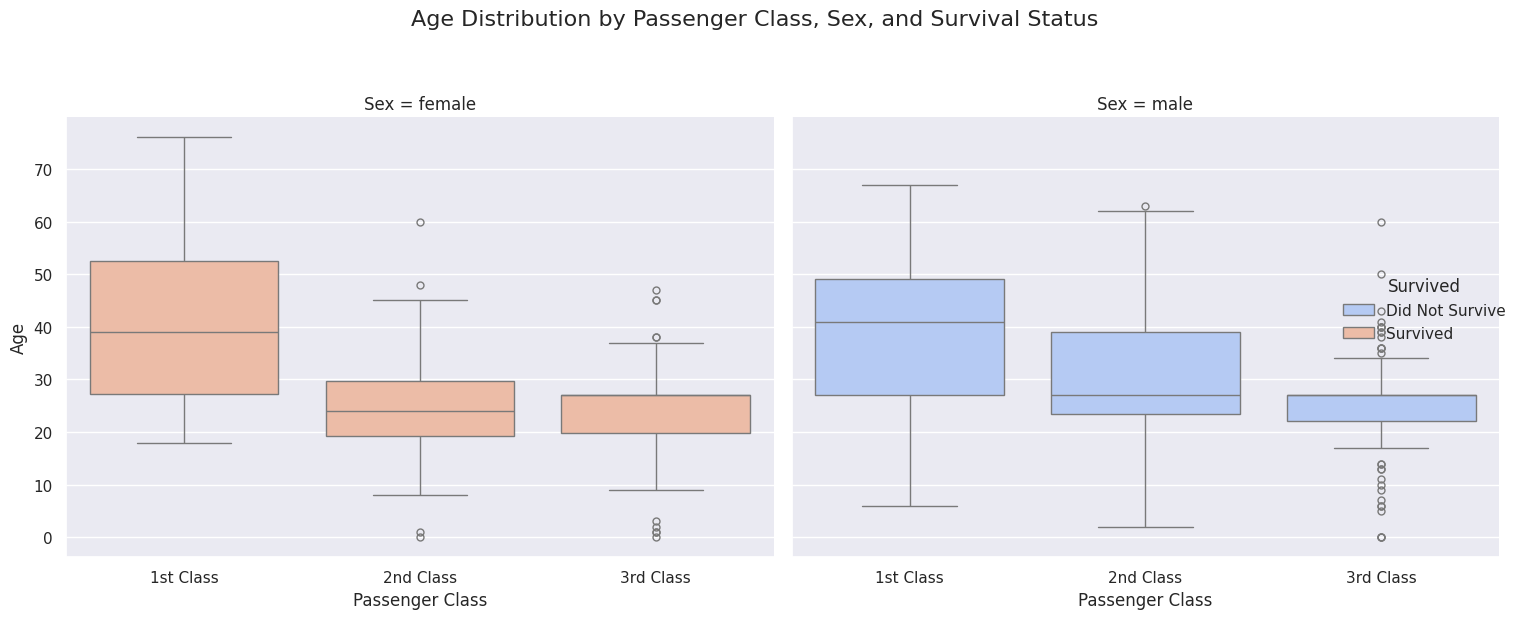

In [ ]:
# Create a grouped box plot to visualize Age distribution by Pclass, Sex, and Survived.
# sns.catplot is used here because it effectively handles faceting (creating separate subplots for 'col' variable).
# 'x' represents 'Pclass', 'y' represents 'Age', 'hue' differentiates by 'Survived' status,
# and 'col' creates separate subplots for each 'Sex'.
# kind='box' specifies that the plot type within each facet should be a box plot.

g = sns.catplot(x='Pclass', y='Age', hue='Survived', col='Sex', data=df, kind='box',
                height=6, aspect=1.2, palette='coolwarm') # Adjust height and aspect for better readability and layout.
g.set_axis_labels('Passenger Class', 'Age') # Set common axis labels for the entire plot.
g.set_titles('Sex = {col_name}') # Set titles for each facet (column) to indicate the gender.

# Customize x-axis labels for clarity on each subplot.
new_xticks = ['1st Class', '2nd Class', '3rd Class']
for ax in g.axes.flat:
    ax.set_xticks(range(len(new_xticks))) # Set numerical tick locations explicitly.
    ax.set_xticklabels(new_xticks)

g._legend.set_title('Survived') # Set the title for the hue legend.
# Update legend labels to be more descriptive.
for t, l in zip(g._legend.texts, ['Did Not Survive', 'Survived']):
    t.set_text(l)

plt.suptitle('Age Distribution by Passenger Class, Sex, and Survival Status', y=1.03, fontsize=16) # Set an overall title for the entire figure.
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent titles and labels from overlapping.
plt.show() # Display the generated plot.

### Insights from Multivariate Analysis Charts

1.  **Correlation Heatmap of Numerical Variables:**
    *   **Insight:** The heatmap reveals important linear relationships between numerical features. 'Fare' shows a moderate positive correlation with 'Survived' (0.19), suggesting that higher fares are associated with better survival chances. Conversely, 'Pclass' has a negative correlation with 'Survived' (-0.11), indicating that lower passenger classes are associated with lower survival rates. 'Age' has a weak positive correlation with 'Survived' (0.01), implying age itself is not a strong linear predictor. Stronger correlations are observed between 'Age' and 'Pclass' (-0.47) and 'Fare' and 'Pclass' (-0.58), confirming that passenger class is highly intertwined with both age distribution and the fare paid.

2.  **Survival Rate by Passenger Class and Sex:**
    *   **Insight:** This chart clearly demonstrates the combined impact of 'Pclass' and 'Sex' on survival. Female passengers consistently have a much higher survival rate than male passengers across all classes. Notably, females in 1st and 2nd class show almost 100% survival, while even female passengers in 3rd class have a significantly better survival rate than males in 1st or 2nd class. Male survival rates are generally low, with 3rd class males having the lowest probability of survival.

3.  **Age Distribution by Passenger Class, Sex, and Survival Status:**
    *   **Insight:** This grouped box plot provides a detailed view of age distribution for survivors and non-survivors across different classes and genders. It shows that:
        *   **Children (especially young ones):** In 1st and 2nd class, child survivors (particularly females) are evident, often with ages concentrated at the lower end of the age spectrum. In 3rd class, young children, regardless of gender, appear to have a slightly better survival chance.
        *   **Adults:** For adult males, survival rates are generally low across all classes, and their age distributions for survivors are scattered. For adult females, the age distribution of survivors in 1st and 2nd class is broad, while in 3rd class, surviving adult females are often younger than non-survivors.
        *   **Age and Pclass Interaction:** Older passengers tend to be concentrated in higher classes (1st and 2nd Pclass). Survival among older individuals is more pronounced in higher classes, particularly for females.

### Summary of Multivariate Analysis
The multivariate analysis reinforces the findings from bivariate analysis, emphasizing that **gender and passenger class are the most dominant factors influencing survival on the Titanic.** Female passengers, especially those in 1st and 2nd class, had a remarkably high survival rate. While age itself has a weak direct correlation with survival, its distribution varies significantly by class and gender, with younger ages having a better chance in some contexts, and older ages being more prevalent in higher, safer classes. The fare paid is also strongly linked to survival, largely due to its high correlation with passenger class. These relationships highlight the complex interplay of socio-economic status, gender roles, and age in determining survival outcomes during the disaster.

## Key Insights from Exploratory Data Analysis

1.  **High Fatality Rate:** The majority of passengers (approximately 63.6% based on the dataset's survival mean of 0.3636) did not survive, indicating a significant loss of life during the event.

2.  **Gender as a Critical Survival Factor:** Female passengers consistently exhibited a substantially higher survival rate compared to male passengers across all demographics, highlighting a pronounced gender disparity in survival outcomes.

3.  **Socio-economic Influence on Survival:** Passenger class was a strong determinant of survival. First-class passengers had the highest survival rates, while third-class passengers had the lowest, indicating that socio-economic status, as reflected by class, significantly impacted survival chances.

4.  **Combined Impact of Class and Gender:** The highest survival probabilities were observed among females in First and Second Class, with nearly 100% survival in these groups. Conversely, male passengers, particularly those in Third Class, faced the lowest survival rates.

5.  **Age-Related Survival Patterns:** Children (specifically the 0-9 age group) generally demonstrated a higher propensity for survival compared to other age brackets. The overall passenger age distribution shows a concentration of young adults.

6.  **Fare Correlates with Survival:** Passengers who paid higher fares tended to have a better chance of survival. This is likely interconnected with the strong negative correlation between `Fare` and `Pclass`, where higher fares are associated with higher (first) passenger classes.

7.  **Initial Data Quality:** The dataset initially contained missing values in the `Age`, `Fare`, and `Cabin` columns, which were subsequently addressed through imputation (median for `Age` and `Fare`, 'Unknown' for `Cabin`) to ensure data completeness for analysis.

## Business Recommendations Based on EDA

**Recommendation 1: Prioritize Safety Protocols for Vulnerable Demographics**
*   **Supporting Evidence:** The analysis consistently shows that female passengers exhibited significantly higher survival rates than males across all demographics. Additionally, first-class passengers had the highest survival rates, while third-class passengers had the lowest. Females in first and second class showed nearly 100% survival, whereas male survival rates were generally low, particularly for third-class males.
*   **Business Rationale:** Implementing gender- and class-aware safety and evacuation protocols ensures that the most vulnerable groups receive appropriate attention and resources during emergencies. This not only enhances ethical responsibility but can also protect brand reputation and customer trust by demonstrating a commitment to equitable safety.

**Recommendation 2: Design Differentiated Safety Briefings and Drills**
*   **Supporting Evidence:** Children (ages 0-9) generally had a higher propensity for survival. Furthermore, passengers traveling with a small number of siblings/spouses (SibSp=1) or parents/children (Parch=1 or Parch=2) had better survival rates than those traveling alone or in very large family groups.
*   **Business Rationale:** Tailored safety communications and drills can significantly improve understanding and adherence to emergency procedures across diverse passenger groups, such as families with young children or individuals traveling alone. This proactive approach can lead to more effective emergency responses and potentially reduce casualties, minimizing legal and reputational risks.

**Recommendation 3: Re-evaluate Value Proposition of Premium Services in Crisis**
*   **Supporting Evidence:** The analysis clearly indicates that first-class passengers, who paid higher fares, consistently had the highest survival rates. This correlation is intertwined with passenger class and the resources or access potentially afforded by it during an emergency.
*   **Business Rationale:** To maintain customer loyalty and justify premium pricing, it is crucial to clearly articulate the tangible benefits of higher-tier services, including safety advantages, particularly in the context of emergency preparedness. This transparency builds trust and manages expectations, especially for high-value customers.

**Recommendation 4: Invest in Comprehensive Data Collection for Passenger Demographics**
*   **Supporting Evidence:** The initial dataset contained missing values for critical variables like 'Age', 'Fare', and especially 'Cabin' (a substantial portion was 'Unknown'). These gaps required imputation for analysis.
*   **Business Rationale:** Accurate and complete demographic and travel-related data (e.g., age, exact cabin location, full family manifest) is foundational for precise risk assessment, targeted emergency planning, and effective resource deployment. Robust data collection systems enable more informed decision-making and better passenger management in both routine operations and crisis situations.

**Recommendation 5: Develop Targeted Communication Strategies for Diverse Embarkation Ports**
*   **Supporting Evidence:** Passengers who embarked from Cherbourg ('C') showed a notably higher survival rate compared to those from Southampton ('S') and Queenstown ('Q'). This suggests potential underlying demographic or cultural differences influencing outcomes.
*   **Business Rationale:** Recognizing and addressing variations in passenger demographics or cultural contexts associated with different embarkation points allows for the development of customized communication strategies and safety information. This can enhance passenger engagement, ensure messages are effectively received, and optimize emergency response coordination based on the specific characteristics of passengers from each port.

## Executive Summary: Titanic Survival Factor Analysis

**Purpose:** This analysis was undertaken to comprehensively explore the Titanic dataset and identify key factors that influenced passenger survival during the disaster. The objective is to derive actionable insights that can inform modern safety protocols, risk assessment, and passenger management strategies for similar large-scale transport operations.

**Dataset Description:** The dataset comprises detailed information for 418 Titanic passengers, including demographics such as age, sex, and name, as well as travel-related attributes like passenger class, fare paid, cabin information, the number of siblings/spouses and parents/children aboard, and the port of embarkation. Each passenger's survival status is also recorded.

**Most Important Findings:**

Our extensive Exploratory Data Analysis revealed several critical determinants of survival:

1.  **Gender Disparity:** Female passengers had a significantly higher survival rate across all passenger classes compared to male passengers, indicating a strong gender-based prioritization during evacuation.
2.  **Socioeconomic Status:** Passenger class was a powerful predictor of survival. First-class passengers consistently experienced the highest survival rates, while third-class passengers faced the lowest. This correlation extends to fare paid, with higher fares generally associated with increased survival probability due to their link with higher classes.
3.  **Combined Factors:** The most favorable survival outcomes were observed among females in First and Second Class, with nearly 100% survival rates. Conversely, male passengers, particularly those in Third Class, had the most dire survival prospects.
4.  **Age and Family Size:** While age itself had a weak direct correlation, children (0-9 years) generally showed a better chance of survival. Furthermore, passengers traveling with small family units (one sibling/spouse or one to two parents/children) exhibited better survival rates than those traveling alone or in very large groups.

**Overall Business Implications:**

The findings underscore the profound impact of demographic and socioeconomic factors on survival outcomes in a crisis. For contemporary operations, these insights highlight the necessity of equitable and effective safety planning that considers diverse passenger profiles. Understanding the influence of factors like gender, social standing, and family dynamics is crucial for developing robust emergency response protocols, ensuring fair resource allocation, and optimizing communication strategies. Proactive data collection and analysis, as demonstrated, are invaluable for continuous improvement in safety and risk management.

**Conclusion:** The analysis clearly demonstrates that survival during the Titanic disaster was not random but systematically influenced by a combination of gender, socioeconomic status (passenger class and fare), and family structure. These evidence-based insights are fundamental for enhancing safety and preparedness in modern contexts.